In [3]:
# ============================================================
# 1. Imports
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Optional models
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

try:
    from catboost import CatBoostRegressor
    catboost_available = True
except ImportError:
    catboost_available = False


In [4]:
# ============================================================
# 2. Load Data
# ============================================================

data_path = "gem_final_combined_data_model.csv"
df = pd.read_csv(data_path)

df.head()


,g_id,address_count,total_pop,percent_60to74,percent_75andUp,percent_households_no_kids,percent_1floor,percent_2floor,percent_3to5floor,percent_own_occ,percent_priv_one,percent_res_one_dwell,income,price_sq_m
0,10101,3,16118,18.31,9.91,41.24,41.39,44.38,13.74,15.59,42.96,67.64,32774,312.70
1,10201,1,1933,21.73,15.52,43.83,71.69,24.71,3.60,4.20,35.91,79.73,24956,245.10
2,10301,4,1943,23.83,16.62,52.42,66.16,31.52,2.32,9.46,41.13,80.54,30022,326.80
3,10302,1,1881,24.46,10.21,46.79,70.85,27.43,1.72,4.45,38.52,80.97,27442,239.20
4,10303,0,2078,22.18,8.57,46.07,54.01,42.48,3.51,3.44,31.98,79.80,30000,278.20


In [5]:
# ============================================================
# 3. Basic Inspection
# ============================================================

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   g_id                        2112 non-null   int64  
 1   address_count               2112 non-null   int64  
 2   total_pop                   2112 non-null   int64  
 3   percent_60to74              2112 non-null   float64
 4   percent_75andUp             2112 non-null   float64
 5   percent_households_no_kids  2112 non-null   float64
 6   percent_1floor              2112 non-null   float64
 7   percent_2floor              2112 non-null   float64
 8   percent_3to5floor           2112 non-null   float64
 9   percent_own_occ             2112 non-null   float64
 10  percent_priv_one            2112 non-null   float64
 11  percent_res_one_dwell       2112 non-null   float64
 12  income                      2112 non-null   int64  
 13  price_sq_m                  2112 

In [6]:
df.describe()


,g_id,address_count,total_pop,percent_60to74,percent_75andUp,percent_households_no_kids,percent_1floor,percent_2floor,percent_3to5floor,percent_own_occ,percent_priv_one,percent_res_one_dwell,income
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,44186.855587,1.146780,4348.134943,19.769242,10.186098,41.346747,41.051548,47.863144,10.664545,9.016591,32.002372,67.195473,24788.359848
std,19719.752164,3.313731,14859.579847,2.911213,2.366813,4.795034,20.317787,15.497812,9.750993,7.884885,5.980364,13.795487,3246.777284
min,10101.000000,0.000000,43.000000,9.300000,2.590000,24.140000,2.200000,2.250000,0.000000,0.000000,14.040000,0.630000,10153.000000
25%,31227.750000,0.000000,1155.750000,17.810000,8.540000,38.475000,23.595000,36.060000,4.117500,2.830000,27.905000,59.367500,22514.750000
50%,41016.500000,0.000000,1865.500000,19.525000,9.900000,41.575000,37.345000,49.755000,7.415000,6.640000,31.485000,68.185000,24562.500000
75%,61629.250000,1.000000,3329.250000,21.420000,11.502500,44.130000,57.840000,60.515000,14.397500,12.925000,35.552500,76.747500,26659.250000
max,92301.000000,67.000000,305314.000000,46.300000,27.640000,66.670000,89.730000,83.190000,89.010000,42.670000,56.930000,96.000000,41355.000000


In [7]:
# ============================================================
# 4. Define Target and Features
# ============================================================

TARGET = "address_count"

X = df.drop(columns=[TARGET, "g_id"])
y = df[TARGET]

# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

categorical_cols, numerical_cols


(['price_sq_m'],
 ['total_pop',
  'percent_60to74',
  'percent_75andUp',
  'percent_households_no_kids',
  'percent_1floor',
  'percent_2floor',
  'percent_3to5floor',
  'percent_own_occ',
  'percent_priv_one',
  'percent_res_one_dwell',
  'income'])

In [8]:
# ============================================================
# 5. Train / Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
# ============================================================
# 6. Preprocessing Pipeline (for sklearn models)
# ============================================================

numeric_transformer = "passthrough"

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


In [22]:
# ============================================================
# 7. Evaluation Helper Function
# ============================================================

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }

In [11]:
linreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linreg_pipeline.fit(X_train, y_train)

linreg_results = evaluate_model(linreg_pipeline, X_test, y_test)
linreg_results


{'RMSE': np.float64(1.4967159547761564),
 'MAE': 0.9895545195244001,
 'R2': 0.3279118385542279}

In [12]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_results = evaluate_model(rf_pipeline, X_test, y_test)
rf_results


{'RMSE': np.float64(1.3922626447145712),
 'MAE': 0.831189913317573,
 'R2': 0.41844631636133156}

In [13]:
if xgb_available:
    xgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                objective="reg:squarederror"
            ))
        ]
    )

    xgb_pipeline.fit(X_train, y_train)
    xgb_results = evaluate_model(xgb_pipeline, X_test, y_test)
    xgb_results
else:
    print("XGBoost not installed.")


In [14]:
xgb_results

{'RMSE': np.float64(1.3802783396498752),
 'MAE': 0.8808932900428772,
 'R2': 0.4284150004386902}

In [15]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


In [16]:
from catboost import CatBoostRegressor


In [17]:
# Identify categorical feature indices (CatBoost needs indices, not names)
cat_features = [X.columns.get_loc(col) for col in categorical_cols]
# Initialize model
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)
# Fit model
cb_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)
# Evaluate
cb_results = evaluate_model(cb_model, X_test, y_test)
cb_results


0:	learn: 3.4977183	test: 1.7735044	best: 1.7735044 (0)	total: 94.1ms	remaining: 1m 33s
100:	learn: 1.0924457	test: 1.1610390	best: 1.1609037 (98)	total: 2.88s	remaining: 25.6s
200:	learn: 0.8057258	test: 1.1691945	best: 1.1592317 (127)	total: 5.78s	remaining: 23s
300:	learn: 0.6391253	test: 1.1834371	best: 1.1592317 (127)	total: 8.59s	remaining: 19.9s
400:	learn: 0.5368284	test: 1.1903626	best: 1.1592317 (127)	total: 12.4s	remaining: 18.5s
500:	learn: 0.4551499	test: 1.1947072	best: 1.1592317 (127)	total: 13.8s	remaining: 13.7s
600:	learn: 0.3935303	test: 1.1994191	best: 1.1592317 (127)	total: 14.9s	remaining: 9.88s
700:	learn: 0.3368940	test: 1.2019175	best: 1.1592317 (127)	total: 16s	remaining: 6.81s
800:	learn: 0.2937194	test: 1.2046819	best: 1.1592317 (127)	total: 17.1s	remaining: 4.24s
900:	learn: 0.2586332	test: 1.2068133	best: 1.1592317 (127)	total: 18.2s	remaining: 2s
999:	learn: 0.2259112	test: 1.2091035	best: 1.1592317 (127)	total: 19.2s	remaining: 0us

bestTest = 1.15923170

{'RMSE': np.float64(1.1592317080712518),
 'MAE': 0.787242788382069,
 'R2': 0.5968302191206787}

In [18]:
feature_importance = cb_model.get_feature_importance()

fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

fi_df.head(20)


,feature,importance
0,total_pop,63.217722
5,percent_2floor,10.918761
10,income,6.970915
2,percent_75andUp,4.060459
7,percent_own_occ,4.039116
4,percent_1floor,2.768863
8,percent_priv_one,2.239442
9,percent_res_one_dwell,1.766697
1,percent_60to74,1.634138
3,percent_households_no_kids,1.223606


In [20]:
results = {
    "Linear Regression": linreg_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
    "CatBoost": cb_results
}

results_df = pd.DataFrame(results).T
results_df


,RMSE,MAE,R2
Linear Regression,1.496716,0.989555,0.327912
Random Forest,1.392263,0.831190,0.418446
XGBoost,1.380278,0.880893,0.428415
CatBoost,1.159232,0.787243,0.596830


/tmp/ipython-input-1453755799.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Model', y='Value', data=results_melted[results_melted['Metric'] == 'RMSE'], palette='viridis')
/tmp/ipython-input-1453755799.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Model', y='Value', data=results_melted[results_melted['Metric'] == 'MAE'], palette='magma')
/tmp/ipython-input-1453755799.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='Model', y='Value', data=results_melted[results_melted['Metric'] ==

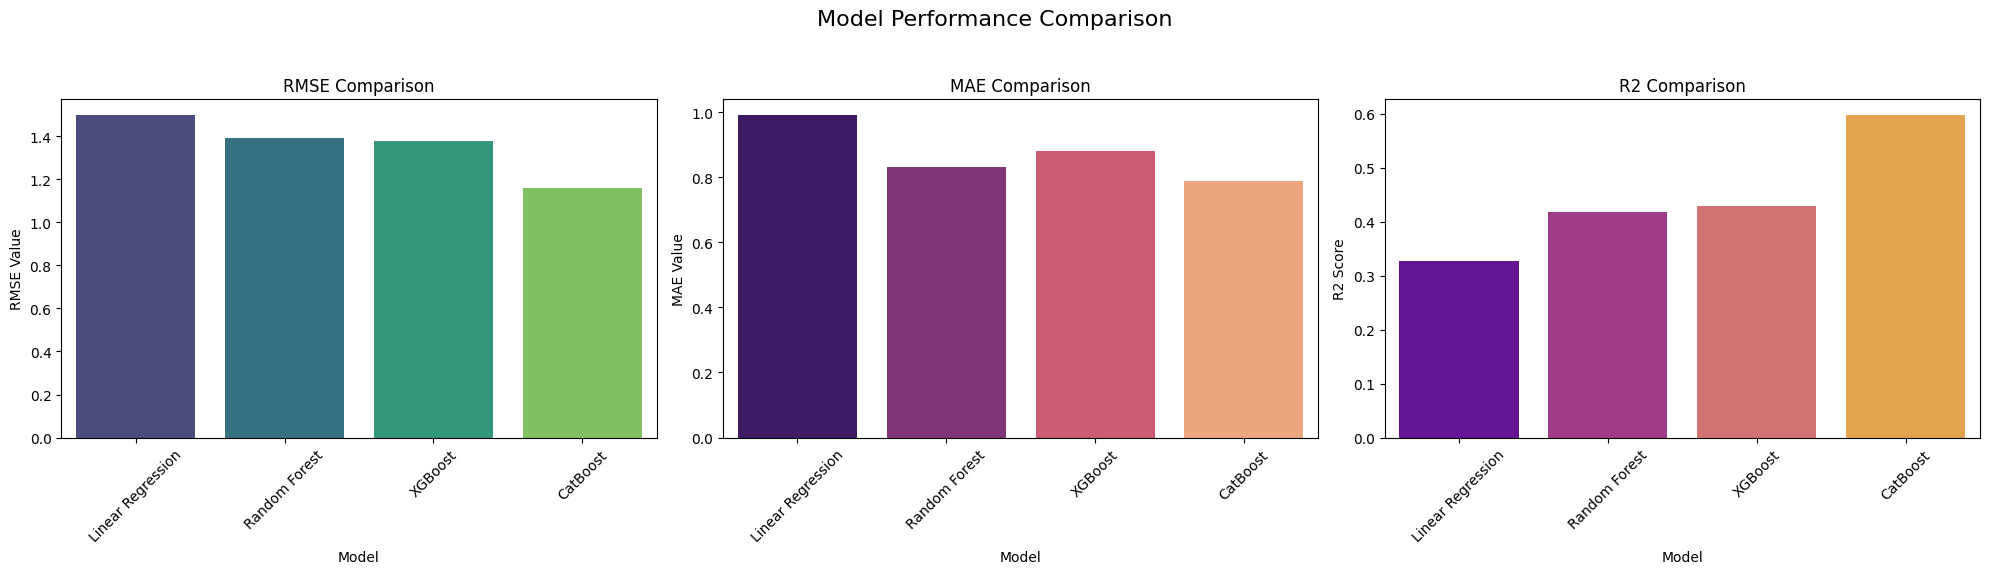

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (melt the DataFrame)
results_melted = results_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Value')
results_melted = results_melted.rename(columns={'index': 'Model'})

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle('Model Performance Comparison', fontsize=16)

# Plot RMSE
sns.barplot(ax=axes[0], x='Model', y='Value', data=results_melted[results_melted['Metric'] == 'RMSE'], palette='viridis')
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE Value')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE
sns.barplot(ax=axes[1], x='Model', y='Value', data=results_melted[results_melted['Metric'] == 'MAE'], palette='magma')
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE Value')
axes[1].tick_params(axis='x', rotation=45)

# Plot R2
sns.barplot(ax=axes[2], x='Model', y='Value', data=results_melted[results_melted['Metric'] == 'R2'], palette='plasma')
axes[2].set_title('R2 Comparison')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()